en una base donde estan los esfuezos pricipales se tiene que
<br>
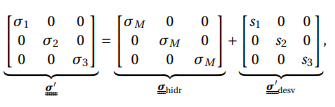
<br>
usando las ecuaciones de lame
<br>
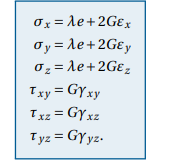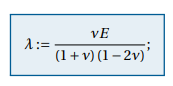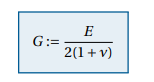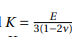
<br>
se buscara llegar a que la aportacion d elos esfuerzos hidroestaticos es el 100% en el cambio volumetrico
<br>
se buscara demostrar que esfuerzo medio =Ke

In [1]:
import sympy as sp
#se tiene que
print("creo la amtriz de esfuerzos hidroestaticos solo para verlo visual")
esfuerzom=sp.symbols("sigma_M")
matrixM=sp.Matrix([
    [esfuerzom,0,0],
    [0,esfuerzom,0],
    [0,0,esfuerzom]
])
display(matrixM)      # para verlo visual
print("--------------------------------------------------------------------")

print("escribo simbolicamente las ecuaciones de lame")
#definimos landa y G, E y v
lamdasimbolico=sp.symbols("lambda")
gsimbolico=sp.symbols("G")
nusimbolico=sp.symbols("nu")
moduloE=sp.symbols("E")

defx=sp.symbols("epsilon_x")
defy=sp.symbols("epsilon_y")
defz=sp.symbols("epsilon_z")


volumetrica=sp.symbols("e")

##defino las ecuaciones de lame
sigmax=(lamdasimbolico*volumetrica)+(2*(gsimbolico*defx))
sigmay=(lamdasimbolico*volumetrica)+(2*(gsimbolico*defy))   #para que se miren
sigmaz=(lamdasimbolico*volumetrica)+(2*(gsimbolico*defz))
display(sigmax,sigmay,sigmaz)
print("-------------------------------------------------------------------------")


##empiezan los calculos
print("le doy valores a e,G,landa")
#ahora si opero
e=defx+defy+defz
g=(moduloE)/(2*(1+nusimbolico))
l=(nusimbolico*moduloE)/((1+nusimbolico)*(1-(2*nusimbolico)))
display(e,g,l)
print("-------------------------------------------------------------------------")
print("reemplazo en las ecuaciones de lame reescribiendola con los nuevos e,G,l, esti corresponde a sigma x, sigmay, sigma z")
#definosigmax,y,z para operar
sigmaX=(l*e)+(2*g*defx)
sigmaY=(l*e)+(2*g*defy)
sigmaZ=(l*e)+(2*g*defz)
display(sigmaX,sigmaY,sigmaZ)
print("------------------------------------------------------------------------")
print("por definicion se tien que sigma m debe ser igual a: ")
sigmaMsimbolico=(sp.symbols("sigma_x")+sp.symbols("sigma_y")+sp.symbols("sigma_z"))/3
display(sigmaMsimbolico)
print("reemplazando")
sigmaMsimbolico2=(sigmax+sigmay+sigmaz)/3
display(sigmaMsimbolico2)
sigmaM=(sigmaX+sigmaY+sigmaZ)/3
display(sigmaM)
print("simplificando")
sigmaMsimplificado=sp.simplify(sigmaM)
display(sigmaMsimplificado)
print("---------------------------------------------------------------------")
print("por lo que el esfuerzo medio es igual al modulo de rigidez por e po lo cual el esfuerzo m es igual a: ")
display(sp.symbols("Ke"))
print("culla aportacion volumetrica es")
display((1/sp.symbols("K"))*(sp.symbols("sigma_m")))
print("------------------------------------------------------------------------------------------")

creo la amtriz de esfuerzos hidroestaticos solo para verlo visual


Matrix([
[sigma_M,       0,       0],
[      0, sigma_M,       0],
[      0,       0, sigma_M]])

--------------------------------------------------------------------
escribo simbolicamente las ecuaciones de lame


2*G*epsilon_x + e*lambda

2*G*epsilon_y + e*lambda

...

---------------------------------------------------------------------
por lo que el esfuerzo medio es igual al modulo de rigidez por e po lo cual el esfuerzo m es igual a: 


Ke

culla aportacion volumetrica es


sigma_m/K

------------------------------------------------------------------------------------------


In [19]:
##aportacion volumetrica de los esfuerzos deviadores
matrixs=sp.Matrix([
    [sp.symbols("S_x"),sp.symbols("tau_xy"),sp.symbols("tau_xz")],
    [sp.symbols("tau_xy"),sp.symbols("S_y"), sp.symbols("tau_yz")],
    [sp.symbols("tau_xz"),sp.symbols("tau_yz"),sp.symbols("S_z")]
])
display(matrixs)
print("-----------------------------------------------------------------------------")
#defino la variable Si
sigx=sp.symbols("sigma_x")
sigy=sp.symbols("sigma_y")
sigz=sp.symbols("sigma_z")

sigm=(sigx+sigy+sigz)/3

sx=sigx-sigm
sy=sigy-sigm
sz=sigz-sigm
print("diagonal de la matriz de esfuerzos desvidadores sx,sy,sz")
display(sx,sy,sz)
print("-----------------------------------------------------------------------------")
##defino la ley de hooke (visual para que despues sepan las operaciones)
epsilonx=(1/moduloE)*(sigx-(nusimbolico*(sigy+sigz)))
epsilony=(1/moduloE)*(sigy-(nusimbolico*(sigx+sigz)))
epsilonz=(1/moduloE)*(sigz-(nusimbolico*(sigy+sigx)))
print("ley de hooke generalizada epsilon x,y,z")
display(epsilonx,epsilony,epsilonz)
print("-----------------------------------------------------------------------------")
##ahora si opero reemplazando los Sx,y,z, en la ley de hooke, de modo que:
epsilonxconS=(1/moduloE)*(sx-(nusimbolico*(sy+sz)))
epsilonyconS=(1/moduloE)*(sy-(nusimbolico*(sx+sz)))
epsilonzconS=(1/moduloE)*(sz-(nusimbolico*(sy+sx)))
print("reemplazando si en la ley de hooke quedanodo asi epsilon x,y,z igual a:")
display(epsilonxconS,epsilonyconS,epsilonzconS)
print("-----------------------------------------------------------------------------")
#ahora vemos la expansion volumetrica que aporta
print("la expansion volumetrica es igual a la suma de:" )
display(sp.symbols("epsilon_x")+sp.symbols("epsilon_y")+sp.symbols("epsilon_z"))
print("por lo cual al sumar lo que halllamos anteriormente nos dara: ")
expansionvolumetricaS=epsilonxconS+epsilonyconS+epsilonzconS
display(sp.simplify(expansionvolumetricaS))

print("es decri que no aporta cambio de volumen los esfuerzos desvidadores")

Matrix([
[   S_x, tau_xy, tau_xz],
[tau_xy,    S_y, tau_yz],
[tau_xz, tau_yz,    S_z]])

-----------------------------------------------------------------------------
diagonal de la matriz de esfuerzos desvidadores sx,sy,sz


2*sigma_x/3 - sigma_y/3 - sigma_z/3

-sigma_x/3 + 2*sigma_y/3 - sigma_z/3

-sigma_x/3 - sigma_y/3 + 2*sigma_z/3

...

-----------------------------------------------------------------------------
la expansion volumetrica es igual a la suma de:


epsilon_x + epsilon_y + epsilon_z

por lo cual al sumar lo que halllamos anteriormente nos dara: 


0

es decri que no aporta cambio de volumen los esfuerzos desvidadores
